<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
# =========================================================
# GOOGLE DRIVE PERSISTENT STORAGE SETUP - SAFE VERSION
# =========================================================

from google.colab import drive
import os
import shutil

assert os.path.exists("/content/drive/MyDrive"), \
    "Google Drive belum mounted"

SAVE_DIR = "/content/drive/MyDrive/router_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Persistent storage OK:", SAVE_DIR)

DRIVE_MOUNT = "/content/drive"
SAVE_DIR = "/content/router_classifier_temp"

drive_ok = False

try:
    drive.mount(
        DRIVE_MOUNT,
        force_remount=False
    )

    SAVE_DIR = (
        f"{DRIVE_MOUNT}/MyDrive/router_classifier"
    )

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )

    drive_ok = True

    print("Google Drive mounted.")
    print("Persistent SAVE_DIR:", SAVE_DIR)

except Exception as e:

    print("WARNING: Google Drive gagal dimount.")
    print(type(e).__name__, e)

    print()
    print("Fallback sementara ke /content.")
    print("DATA BISA HILANG jika runtime restart.")

    SAVE_DIR = "/content/router_classifier_temp"

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )


# =========================================================
# PATH CONFIG
# =========================================================

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

BASE_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"
CURRENT_DATASET_PATH = f"{SAVE_DIR}/router_dataset_current.csv"
CURRENT_MODEL_PATH = f"{SAVE_DIR}/router_classifier_current.joblib"
ROUND_LOG_PATH = f"{SAVE_DIR}/router_tuning_rounds.csv"


print()
print("=" * 60)
print("STORAGE STATUS")
print("=" * 60)

print("Drive mounted :", drive_ok)
print("SAVE_DIR      :", SAVE_DIR)

print()

MessageError Error: credential propagation was unsuccessful

Fallback sementara ke /content.
DATA BISA HILANG jika runtime restart.

STORAGE STATUS
Drive mounted : False
SAVE_DIR      : /content/router_classifier_temp



In [99]:
# 1. Install library
!pip install -q datasets pandas requests tqdm scikit-learn sentence-transformers joblib

In [100]:
# 2. Download dataset Indonesia

from datasets import load_dataset

ds = load_dataset(
    "ilhamfadheel/alpaca-cleaned-indonesian",
    split="train"
)

print(ds)
print(ds[0])

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 45631
})
{'instruction': 'Sebutkan tiga senyawa organik.', 'input': '', 'output': 'Tiga senyawa organik adalah glukosa (C6H12O6), metana (CH4), dan etanol (C2H5OH).'}


In [101]:
# # Ambil 5.000 prompt dulu
# SAMPLE_SIZE = 5000

# ds_small = ds.shuffle(seed=42).select(
#     range(min(SAMPLE_SIZE, len(ds)))
# )

# def build_prompt(row):
#     instruction = row["instruction"].strip()
#     input_text = row["input"].strip()

#     if input_text:
#         return instruction + "\n" + input_text

#     return instruction

# prompts = [build_prompt(x) for x in ds_small]

# print("Jumlah prompt:", len(prompts))

# for x in prompts[:5]:
#     print("\n---")
#     print(x)

In [102]:
# 4. Buat label router SIMPLE
# Fakta sederhana, lookup, klasifikasi sederhana,
# jawaban singkat, operasi mudah.

# GENERAL
# Penjelasan umum yang tidak membutuhkan reasoning berat.

# REASONING
# Analisis, matematika, planning, comparison,
# trade-off, deduksi, multi-step problem.

# CODING_SIMPLE
# Generate snippet sederhana, regex, SQL sederhana,
# fungsi kecil, syntax.

# CODING_COMPLEX
# Debugging kompleks, architecture, multi-file,
# race condition, performance, security review.

# TRANSFORM
# Translation, summarization, rewrite,
# extract, shorten, formatting.

# CREATIVE
# Story, brainstorming kreatif, slogan,
# dialog, ide kreatif.

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

In [103]:
# 5. Konfigurasi API teacher
import os

BASE_URL = "https://openrouter.ai/api/v1/chat/completions"
API_KEY = "ISI_API_KEY"
MODEL = "openrouter/free"

TEMPERATURE = 0
TIMEOUT = 90

In [104]:
from google.colab import userdata
API_KEY = userdata.get('OPEN_ROUTER')

In [105]:
# 6. Teacher prompt
SYSTEM_PROMPT = """
You are labeling user prompts for an AI model router.

Classify each prompt into EXACTLY ONE label:

SIMPLE
- Simple factual questions
- Easy lookup
- Basic classification
- Very short/simple task
- Does not require substantial reasoning

GENERAL
- General explanation
- Normal knowledge question
- Moderate general assistant task
- Does not clearly belong to another category

REASONING
- Mathematics
- Multi-step reasoning
- Planning
- Comparison and trade-offs
- Analysis
- Deduction
- Complex decision making

CODING_SIMPLE
- Small code snippets
- Simple functions
- Regex
- Basic SQL
- Syntax questions
- Straightforward programming tasks

CODING_COMPLEX
- Complex debugging
- Software architecture
- Multi-component systems
- Race conditions
- Security/code review
- Performance optimization
- Complex implementation

TRANSFORM
- Translation
- Summarization
- Rewrite
- Shortening
- Extraction
- Reformatting
- Changing an existing text without requiring substantial new reasoning

CREATIVE
- Story writing
- Creative brainstorming
- Dialogue
- Slogans
- Fiction
- Creative ideation

Important rules:

1. Classify based on USER INTENT, not individual keywords.
2. The prompt may be Indonesian, English, or mixed Indonesian-English.
3. Technical words do NOT automatically mean CODING.
4. Mentioning a language such as "Bahasa Inggris" does NOT automatically mean TRANSFORM.
5. "Explain" does NOT automatically mean REASONING.
6. Choose CODING_COMPLEX only if strong technical reasoning or debugging is actually required.
7. Use SIMPLE for genuinely easy tasks.
8. Return valid JSON only.

Output schema:

{
  "label": "ONE_LABEL",
  "difficulty": 1,
  "confidence": 0.95
}

difficulty must be integer 1-5.
confidence must be number 0-1.
"""

In [106]:
# 7. Fungsi call API
import requests
import time

def call_teacher(prompt):
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": MODEL,
        "temperature": 0,
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    }

    print("  -> POST", BASE_URL)
    print("  -> model:", MODEL)

    start = time.time()

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,

        # jangan 90 detik dulu untuk debugging
        timeout=(10, 30)
    )

    print(
        f"  <- HTTP {response.status_code}"
        f" ({time.time() - start:.2f}s)"
    )

    response.raise_for_status()

    data = response.json()

    return data["choices"][0]["message"]["content"]

In [107]:
# 8. Parser JSON yang lebih tahan error

import re

def parse_teacher_output(text):
    text = text.strip()

    match = re.search(r'\{[\s\S]*?\}', text)

    if not match:
        raise ValueError(
            f"Tidak menemukan JSON: {text[:300]}"
        )

    data = json.loads(match.group())

    label = data.get("label")
    difficulty = int(data.get("difficulty"))
    confidence = float(data.get("confidence"))

    if label not in LABELS:
        raise ValueError(f"Label invalid: {label}")

    if not 1 <= difficulty <= 5:
        raise ValueError("Difficulty invalid")

    if not 0 <= confidence <= 1:
        raise ValueError("Confidence invalid")

    return {
        "label": label,
        "difficulty": difficulty,
        "confidence": confidence
    }

In [108]:
# 9. Tes 1 prompt dulu

test_prompt = """
review architecture backend saya dan cari kemungkinan
race condition serta bottleneck performance
"""

raw = call_teacher(test_prompt)

print("RAW:")
print(raw)

parsed = parse_teacher_output(raw)

print("\nPARSED:")
print(parsed)

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.93s)
RAW:
{
  "label": "CODING_COMPLEX",
  "difficulty": 4,
  "confidence": 0.95
}

PARSED:
{'label': 'CODING_COMPLEX', 'difficulty': 4, 'confidence': 0.95}


In [109]:
# 11. Teacher labeling + checkpoint
import pandas as pd
import os

CHECKPOINT_PATH = "/content/router_teacher_checkpoint.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_result = pd.read_csv(CHECKPOINT_PATH)

    print(
        "Resume checkpoint:",
        len(df_result),
        "prompt"
    )

else:
    df_result = pd.DataFrame(
        columns=[
            "prompt",
            "label",
            "difficulty",
            "confidence",
            "status"
        ]
    )

    print("Checkpoint belum ada, mulai dari 0")

print(df_result.head())
print("Rows:", len(df_result))

Resume checkpoint: 100 prompt
                                              prompt      label  difficulty  \
0  Beri saya pertanyaan untuk ditanyakan kepada s...     SIMPLE           1   
1  Jelaskan faktor-faktor yang berkontribusi terh...    GENERAL           3   
2  Jelaskan seperti apa hari-hari musim panas pad...     SIMPLE           1   
3  Tulis ulang kalimat berikut untuk mendapatkan ...  TRANSFORM           1   
4  Tuliskan sebuah cerita tentang seorang wanita ...   CREATIVE           3   

   confidence status  
0        0.95     ok  
1        0.93     ok  
2        0.95     ok  
3        0.95     ok  
4        0.95     ok  
Rows: 100


In [110]:
# #12. Loop labeling DEPRECTATED FLOW

# from tqdm.auto import tqdm
# import time

# START_INDEX = len(df_result)

# SAVE_EVERY = 20
# MAX_RETRIES = 3

# results = df_result.to_dict("records")

# print("Mulai dari index:", START_INDEX)
# print("Total prompt:", len(prompts))

# for i in tqdm(
#     range(START_INDEX, len(prompts)),
#     initial=START_INDEX,
#     total=len(prompts)
# ):

#     prompt = prompts[i]
#     success = False

#     for attempt in range(MAX_RETRIES):
#         try:
#             raw = call_teacher(prompt)
#             parsed = parse_teacher_output(raw)

#             results.append({
#                 "prompt": prompt,
#                 "label": parsed["label"],
#                 "difficulty": parsed["difficulty"],
#                 "confidence": parsed["confidence"],
#                 "status": "ok"
#             })

#             success = True
#             break

#         except Exception as e:
#             print(
#                 f"\nError index {i}, "
#                 f"attempt {attempt + 1}/{MAX_RETRIES}: "
#                 f"{type(e).__name__}: {e}"
#             )

#             try:
#                 print("RAW RESPONSE:", raw[:500])
#             except:
#                 pass

#         time.sleep(2 * (attempt + 1))

#     if not success:
#         results.append({
#             "prompt": prompt,
#             "label": None,
#             "difficulty": None,
#             "confidence": None,
#             "status": "error"
#         })

#     if (
#         (i + 1) % SAVE_EVERY == 0
#         or i == len(prompts) - 1
#     ):
#         pd.DataFrame(results).to_csv(
#             CHECKPOINT_PATH,
#             index=False
#         )

#         print(
#             f"\nCheckpoint saved: "
#             f"{len(results)}/{len(prompts)}"
#         )

# print("Labeling selesai")

In [111]:
# 13. Load hasil final LOAD CHECKPOINT / FINAL RESULT

import pandas as pd

df = pd.read_csv(CHECKPOINT_PATH)

print("Total tersimpan:", len(df))
print()

print("Status:")
print(df["status"].value_counts(dropna=False))
print()

print("Label:")
print(df["label"].value_counts(dropna=False))
print()

print("Shape:", df.shape)

Total tersimpan: 100

Status:
status
ok    100
Name: count, dtype: int64

Label:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Shape: (100, 5)


In [112]:
# 14. Hapus request yang gagal

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean.to_csv(
    "/content/router_seed_indonesia.csv",
    index=False
)

print("Seed Indonesia:", len(df_clean))

Seed Indonesia: 100


In [113]:
# 15. Lihat distribusi label

print(
    df_clean["label"].value_counts()
)

print()

print(
    df_clean["label"]
    .value_counts(normalize=True)
    .round(3)
)

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

label
SIMPLE           0.35
CREATIVE         0.23
GENERAL          0.22
TRANSFORM        0.13
REASONING        0.05
CODING_SIMPLE    0.02
Name: proportion, dtype: float64


In [114]:
# 16. Filter confidence rendah

MIN_CONFIDENCE = 0.80

df_high = df_clean[
    df_clean["confidence"] >= MIN_CONFIDENCE
].copy()

print(
    "High confidence:",
    len(df_high)
)

print()

print(
    df_high["label"].value_counts()
)

High confidence: 100

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [115]:
# 17. Lihat prompt yang teacher tidak yakin

uncertain = df_clean.sort_values(
    "confidence"
)

print(
    uncertain[
        [
            "prompt",
            "label",
            "difficulty",
            "confidence"
        ]
    ]
    .head(30)
    .to_string(index=False)
)

                                                                                                                                                                                                                                                                                                                                     prompt         label  difficulty  confidence
                                                                                                                                                                                                                                                                                    Buat iklan lowongan pekerjaan untuk copy editor online.      CREATIVE           2        0.85
                                                                                                                                                                                                                                                             Hasilka

In [116]:
# 18. Lihat contoh setiap kategori

for label in LABELS:

    print("\n")
    print("=" * 70)
    print(label)
    print("=" * 70)

    samples = (
        df_high[
            df_high["label"] == label
        ]
        .sample(
            min(
                10,
                len(
                    df_high[
                        df_high["label"]
                        == label
                    ]
                )
            ),
            random_state=42
        )
    )

    for _, row in samples.iterrows():

        print(
            f"\n[{row['confidence']:.2f}]",
            row["prompt"][:300]
        )



SIMPLE

[0.95] Temukan kelipatan persekutuan terkecil dari 15 dan 20

[0.95] Tulis persamaan untuk menghitung total biaya suatu produk.
Harga produk = $24
Kuantitas = 3
Biaya pengiriman = $8

[0.95] Jelaskan arti frasa "carpe diem".

[0.95] Kelompokkan kata-kata menurut bagian pidatonya.
Kuat, panjang, apel

[0.95] Bacalah pengamatan berikut dan beri label sebagai kekuatan atau kelemahan.
Situs web ini ramah pengguna dan mudah dinavigasi.

[0.96] Sebutkan ciri-ciri mobil tahun 1950an.

[0.95] Pilihlah kalimat yang paling mencerminkan pendapat yang diberikan
Saya lebih suka melakukan aktivitas lain selain berbelanja di akhir pekan

[0.95] Cocokkan setiap item dengan salah satu dari empat musim.
Salju, Berkemah, Pantai, Anggur

[0.98] Kategorikan kata berikut ke dalam kelas kata yang sesuai.
Cantik

[0.95] Jika diberi resep, sarankan hidangan yang sesuai untuk menyajikannya.
Resep: Lasagna Keju


GENERAL

[0.93] Jelaskan faktor-faktor yang berkontribusi terhadap krisis ekonomi global s

In [117]:
# 19. Export teacher dataset
FINAL_DATASET = (
    "/content/router_teacher_labeled.csv"
)

df_high.to_csv(
    FINAL_DATASET,
    index=False
)

print(FINAL_DATASET)

/content/router_teacher_labeled.csv


In [118]:
# 20. Training classifier baru

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

X = embedding_model.encode(
    df_high["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y = df_high["label"].values

print(X.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

(100, 384)


In [119]:
# 21. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    len(X_train),
    len(X_test)
)

80 20


In [120]:
# 22. Train Logistic Regression
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)

classifier.fit(
    X_train,
    y_train
)

print("Done")

Done


In [121]:
# 23. Evaluate

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred = classifier.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print()

print(
    classification_report(
        y_test,
        pred,
        digits=3
    )
)

Accuracy: 0.65

              precision    recall  f1-score   support

    CREATIVE      1.000     0.800     0.889         5
     GENERAL      0.667     0.500     0.571         4
   REASONING      0.000     0.000     0.000         1
      SIMPLE      0.538     1.000     0.700         7
   TRANSFORM      0.000     0.000     0.000         3

    accuracy                          0.650        20
   macro avg      0.441     0.460     0.432        20
weighted avg      0.572     0.650     0.582        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [122]:
# 24. Confusion matrix
from sklearn.metrics import confusion_matrix

labels_sorted = list(
    classifier.classes_
)

cm = confusion_matrix(
    y_test,
    pred,
    labels=labels_sorted
)

cm_df = pd.DataFrame(
    cm,
    index=labels_sorted,
    columns=labels_sorted
)

print(cm_df)

               CODING_SIMPLE  CREATIVE  GENERAL  REASONING  SIMPLE  TRANSFORM
CODING_SIMPLE              0         0        0          0       0          0
CREATIVE                   0         4        0          0       1          0
GENERAL                    0         0        2          0       2          0
REASONING                  0         0        1          0       0          0
SIMPLE                     0         0        0          0       7          0
TRANSFORM                  0         0        0          0       3          0


In [123]:
# 25. Test prompt Indonesia nyata
test_prompts = [
    "berapa 15 persen dari 500",

    "jelaskan fungsi docker compose",

    "bandingkan REST dan GraphQL "
    "untuk backend aplikasi besar",

    "buat regex untuk validasi email",

    "debug kenapa service systemd saya "
    "restart terus dan cek kemungkinan "
    "race condition",

    "ringkas tulisan ini menjadi 5 poin",

    "terjemahkan kalimat ini ke bahasa jepang",

    "buat cerita pendek tentang robot kecil",

    "kenapa request ke API direct cepat "
    "tapi lewat router jadi lambat",

    "review architecture backend saya, "
    "analisis bottleneck, retry strategy, "
    "dan desain ulang flow request"
]

emb = embedding_model.encode(
    test_prompts,
    normalize_embeddings=True
)

prediction = classifier.predict(
    emb
)

probability = classifier.predict_proba(
    emb
)

for prompt, label, probs in zip(
    test_prompts,
    prediction,
    probability
):

    confidence = probs.max()

    print("\nPROMPT:")
    print(prompt)

    print(
        "ROUTE:",
        label
    )

    print(
        "CONFIDENCE:",
        round(
            float(confidence),
            3
        )
    )


PROMPT:
berapa 15 persen dari 500
ROUTE: SIMPLE
CONFIDENCE: 0.448

PROMPT:
jelaskan fungsi docker compose
ROUTE: SIMPLE
CONFIDENCE: 0.433

PROMPT:
bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: SIMPLE
CONFIDENCE: 0.384

PROMPT:
buat regex untuk validasi email
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
debug kenapa service systemd saya restart terus dan cek kemungkinan race condition
ROUTE: SIMPLE
CONFIDENCE: 0.383

PROMPT:
ringkas tulisan ini menjadi 5 poin
ROUTE: SIMPLE
CONFIDENCE: 0.52

PROMPT:
terjemahkan kalimat ini ke bahasa jepang
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
buat cerita pendek tentang robot kecil
ROUTE: SIMPLE
CONFIDENCE: 0.336

PROMPT:
kenapa request ke API direct cepat tapi lewat router jadi lambat
ROUTE: SIMPLE
CONFIDENCE: 0.375

PROMPT:
review architecture backend saya, analisis bottleneck, retry strategy, dan desain ulang flow request
ROUTE: GENERAL
CONFIDENCE: 0.399


In [124]:
# # 26. Simpan classifier
import joblib

MODEL_PATH = (
    "/content/router_classifier_v2.joblib"
)

joblib.dump(
    classifier,
    MODEL_PATH
)

print(MODEL_PATH)

print(df_high["label"].value_counts())

/content/router_classifier_v2.joblib
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [125]:
# 27. TARGET BALANCE

TARGET_PER_LABEL = 60

current_counts = df_high["label"].value_counts()

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

needed = {}

for label in LABELS:
    current = int(current_counts.get(label, 0))
    needed[label] = max(0, TARGET_PER_LABEL - current)

print("Current:")
print(current_counts)

print("\nNeed additional:")
for label, count in needed.items():
    print(label, ":", count)

Current:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Need additional:
SIMPLE : 25
GENERAL : 38
REASONING : 55
CODING_SIMPLE : 58
CODING_COMPLEX : 60
TRANSFORM : 47
CREATIVE : 37


In [126]:
# 28. EXTRA PROMPTS

extra_prompts = [
    # CODING_SIMPLE
    "buat regex untuk validasi email",
    "buat function python untuk parsing json",
    "buat query SQL untuk mengambil 10 user terbaru",
    "buat fungsi javascript untuk debounce",
    "buat contoh request fetch API sederhana",

    # CODING_COMPLEX
    "debug kenapa service systemd restart terus setelah dependency timeout",
    "review architecture microservice dan cari race condition",
    "analisis bottleneck concurrency pada worker queue",
    "review strategi retry dan circuit breaker untuk API yang sering gagal",
    "analisis security dan performance flow authentication",

    # REASONING
    "bandingkan REST dan GraphQL untuk aplikasi besar",
    "analisis tradeoff monolith dan microservice",
    "tentukan pendekatan terbaik untuk mengurangi latency API",
    "bandingkan dua strategi caching dan jelaskan tradeoffnya",
    "pilih arsitektur terbaik berdasarkan constraint resource kecil",
]

print("Extra prompts:", len(extra_prompts))

Extra prompts: 15


In [127]:
# 29. TEACHER LABEL EXTRA

extra_results = []

for i, prompt in enumerate(extra_prompts, start=1):

    print(f"\n[{i}/{len(extra_prompts)}]")

    try:
        raw = call_teacher(prompt)
        parsed = parse_teacher_output(raw)

        extra_results.append({
            "prompt": prompt,
            "label": parsed["label"],
            "difficulty": parsed["difficulty"],
            "confidence": parsed["confidence"],
            "status": "ok"
        })

        print(parsed)

    except Exception as e:
        print("ERROR:", e)

        extra_results.append({
            "prompt": prompt,
            "label": None,
            "difficulty": None,
            "confidence": None,
            "status": "error"
        })


[1/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.29s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[2/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.31s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[3/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.51s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[4/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.95s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[5/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (13.12s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[6/15]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.

In [128]:
# 30. SAVE EXTRA DATA

df_extra = pd.DataFrame(extra_results)

EXTRA_PATH = "/content/router_teacher_extra.csv"

df_extra.to_csv(
    EXTRA_PATH,
    index=False
)

print("Saved:", EXTRA_PATH)
print()
print(df_extra["label"].value_counts(dropna=False))

Saved: /content/router_teacher_extra.csv

label
REASONING         7
CODING_SIMPLE     5
CODING_COMPLEX    2
None              1
Name: count, dtype: int64


In [129]:
# 31. MERGE OLD + EXTRA

df_old = df_high.copy()

df_new = pd.read_csv(
    "/content/router_teacher_extra.csv"
)

df_new = df_new[
    (df_new["status"] == "ok") &
    (df_new["confidence"] >= 0.80)
].copy()

df_balanced = pd.concat(
    [df_old, df_new],
    ignore_index=True
)

df_balanced = df_balanced.drop_duplicates(
    subset=["prompt"]
)

print("Total:", len(df_balanced))
print()
print(df_balanced["label"].value_counts())

Total: 114

label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING         12
CODING_SIMPLE      7
CODING_COMPLEX     2
Name: count, dtype: int64


In [130]:
# 32. RETRAIN V3 - SAFE VERSION


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# cek distribusi
counts = df_balanced["label"].value_counts()

print("Distribusi sebelum filter:")
print(counts)
print()

# hanya kelas dengan minimal 2 contoh
valid_labels = counts[counts >= 2].index

df_v3 = df_balanced[
    df_balanced["label"].isin(valid_labels)
].copy()

print("Distribusi setelah filter:")
print(df_v3["label"].value_counts())
print()

# embedding ulang
X_v3 = embedding_model.encode(
    df_v3["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y_v3 = df_v3["label"].values

# split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y_v3,
    test_size=0.2,
    random_state=42,
    stratify=y_v3
)

# train
classifier_v3 = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

classifier_v3.fit(
    X_train_v3,
    y_train_v3
)

# evaluate
pred_v3 = classifier_v3.predict(X_test_v3)

print(
    classification_report(
        y_test_v3,
        pred_v3,
        digits=3,
        zero_division=0
    )
)

Distribusi sebelum filter:
label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING         12
CODING_SIMPLE      7
CODING_COMPLEX     2
Name: count, dtype: int64

Distribusi setelah filter:
label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING         12
CODING_SIMPLE      7
CODING_COMPLEX     2
Name: count, dtype: int64



Batches:   0%|          | 0/2 [00:00<?, ?it/s]

               precision    recall  f1-score   support

CODING_SIMPLE      0.500     1.000     0.667         1
     CREATIVE      0.429     0.600     0.500         5
      GENERAL      1.000     0.400     0.571         5
    REASONING      0.000     0.000     0.000         2
       SIMPLE      0.400     0.286     0.333         7
    TRANSFORM      0.500     1.000     0.667         3

     accuracy                          0.478        23
    macro avg      0.471     0.548     0.456        23
 weighted avg      0.519     0.478     0.450        23



In [131]:
print(df_balanced["label"].value_counts())

label
SIMPLE            35
CREATIVE          23
GENERAL           22
TRANSFORM         13
REASONING         12
CODING_SIMPLE      7
CODING_COMPLEX     2
Name: count, dtype: int64


In [140]:
# =========================================================
# AUTO TUNING SYSTEM - FULL VERSION
# Run setup atas sekali, lalu cell ini bisa dirun berulang
# =========================================================

import os
import re
import json
import time
import joblib
import pandas as pd

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)


# =========================================================
# 1. CONFIG
# =========================================================

TARGET_PER_LABEL = 30
MIN_CONFIDENCE = 0.80

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

CATEGORY_DESCRIPTIONS = {

    "SIMPLE":
        "Simple factual questions, easy lookup, simple "
        "calculation, basic classification, short easy tasks.",

    "GENERAL":
        "Normal general assistant questions and general "
        "explanations without substantial reasoning.",

    "REASONING":
        "Non-coding or general analytical tasks requiring "
        "comparison, planning, trade-offs, deduction, mathematics, "
        "or multi-step reasoning. "
        "If the task specifically asks to debug, implement, review, "
        "optimize, secure, or architect software/code, classify it "
        "as CODING_COMPLEX instead.",

    "CODING_SIMPLE":
        "Small programming tasks such as regex, basic SQL, "
        "short functions, syntax questions, simple scripts.",

    "CODING_COMPLEX":
        "Software engineering tasks requiring substantial technical "
        "reasoning involving actual software systems, code, APIs, "
        "backend/frontend architecture, debugging, concurrency, "
        "race conditions, security review, performance optimization, "
        "distributed systems, or multi-component implementation. "
        "A generic technology comparison without an implementation "
        "or software engineering task is REASONING.",

    "TRANSFORM":
        "Translation, summarization, rewriting, extraction, "
        "shortening, formatting, or transforming existing text.",

    "CREATIVE":
        "Creative writing, stories, dialogue, brainstorming, "
        "slogans, fiction, and creative ideation."
}


# =========================================================
# 2. FILE PATHS
# =========================================================


SAVE_DIR = "/content/drive/MyDrive/router_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

BASE_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"
CURRENT_DATASET_PATH = f"{SAVE_DIR}/router_dataset_current.csv"
CURRENT_MODEL_PATH = f"{SAVE_DIR}/router_classifier_current.joblib"
ROUND_LOG_PATH = f"{SAVE_DIR}/router_tuning_rounds.csv"



# =========================================================
# 3. LOAD CURRENT DATASET
# =========================================================

def load_current_dataset():

    if not os.path.exists(BASE_PATH):
        raise FileNotFoundError(
            f"Base dataset tidak ditemukan: {BASE_PATH}"
        )

    df_base = pd.read_csv(BASE_PATH)

    df_base = df_base[
        (df_base["status"] == "ok") &
        (df_base["confidence"] >= MIN_CONFIDENCE)
    ].copy()

    if os.path.exists(EXTRA_ALL_PATH):

        df_extra = pd.read_csv(
            EXTRA_ALL_PATH
        )

        df_extra = df_extra[
            (df_extra["status"] == "ok") &
            (df_extra["confidence"] >= MIN_CONFIDENCE)
        ].copy()

    else:

        df_extra = pd.DataFrame(
            columns=df_base.columns
        )

    df_all = pd.concat(
        [
            df_base,
            df_extra
        ],
        ignore_index=True
    )

    df_all = df_all.drop_duplicates(
        subset=["prompt"],
        keep="first"
    )

    return df_all


# =========================================================
# 4. CHECK MISSING LABELS
# =========================================================

def calculate_missing(
    df,
    target=TARGET_PER_LABEL
):

    counts = df[
        "label"
    ].value_counts()

    result = {}

    for label in LABELS:

        current = int(
            counts.get(
                label,
                0
            )
        )

        need = max(
            0,
            target - current
        )

        result[label] = {
            "current": current,
            "need": need
        }

    return result


# =========================================================
# 5. GENERATE TARGETED PROMPTS
# =========================================================

def generate_prompts_for_label(
    label,
    count
):

    request = f"""
Generate exactly {count} diverse USER prompts.

Target category:
{label}

Definition:
{CATEGORY_DESCRIPTIONS[label]}

Language distribution:
- approximately 60% Indonesian
- approximately 25% English
- approximately 15% mixed Indonesian-English

Requirements:
- natural user requests
- varied subject matter
- varied sentence lengths
- no answers
- no duplicates
- do not explicitly mention the category name
- return ONLY a valid JSON array of strings

Example:
[
  "prompt pertama",
  "prompt kedua"
]
"""

    raw = call_teacher(
        request
    )

    match = re.search(
        r'\[[\s\S]*\]',
        raw
    )

    if not match:

        raise ValueError(
            "JSON array tidak ditemukan: "
            + raw[:300]
        )

    data = json.loads(
        match.group()
    )

    if not isinstance(
        data,
        list
    ):
        raise ValueError(
            "Teacher tidak menghasilkan list."
        )

    clean = []

    for item in data:

        if (
            isinstance(item, str)
            and item.strip()
        ):
            clean.append(
                item.strip()
            )

    return clean


# =========================================================
# 6. TEACHER VALIDATION
# =========================================================

def validate_prompts(
    prompts_to_validate
):

    results = []

    for prompt in tqdm(
        prompts_to_validate,
        desc="Teacher validation"
    ):

        success = False

        for attempt in range(3):

            try:

                raw = call_teacher(
                    prompt
                )

                parsed = (
                    parse_teacher_output(
                        raw
                    )
                )

                results.append({
                    "prompt":
                        prompt,

                    "label":
                        parsed["label"],

                    "difficulty":
                        parsed["difficulty"],

                    "confidence":
                        parsed["confidence"],

                    "status":
                        "ok"
                })

                success = True
                break

            except Exception as e:

                print(
                    "\nTeacher error:",
                    type(e).__name__,
                    e
                )

                time.sleep(
                    2 * (
                        attempt + 1
                    )
                )

        if not success:

            results.append({
                "prompt":
                    prompt,

                "label":
                    None,

                "difficulty":
                    None,

                "confidence":
                    None,

                "status":
                    "error"
            })

    return results


# =========================================================
# 7. APPEND EXTRA DATA
# =========================================================

def append_extra_results(
    new_results
):

    df_new = pd.DataFrame(
        new_results
    )

    if os.path.exists(
        EXTRA_ALL_PATH
    ):

        df_old = pd.read_csv(
            EXTRA_ALL_PATH
        )

        df_extra = pd.concat(
            [
                df_old,
                df_new
            ],
            ignore_index=True
        )

    else:

        df_extra = df_new

    df_extra = (
        df_extra
        .drop_duplicates(
            subset=["prompt"],
            keep="first"
        )
    )

    df_extra.to_csv(
        EXTRA_ALL_PATH,
        index=False
    )

    return df_extra


# =========================================================
# 8. TRAIN ROUTER
# =========================================================

def train_router(
    df
):

    print(
        "\nGenerating embeddings..."
    )

    X = embedding_model.encode(
        df["prompt"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    y = df[
        "label"
    ].values

    counts = pd.Series(
        y
    ).value_counts()

    if counts.min() < 2:

        print(
            "\nBelum bisa split stratified."
        )

        print(
            counts
        )

        return None, None

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            random_state=42,
            stratify=y
        )
    )

    classifier = (
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )

    classifier.fit(
        X_train,
        y_train
    )

    prediction = (
        classifier.predict(
            X_test
        )
    )

    accuracy = (
        accuracy_score(
            y_test,
            prediction
        )
    )

    macro_f1 = (
        f1_score(
            y_test,
            prediction,
            average="macro",
            zero_division=0
        )
    )

    print(
        "\nAccuracy:",
        round(
            accuracy,
            3
        )
    )

    print(
        "Macro F1:",
        round(
            macro_f1,
            3
        )
    )

    print()

    print(
        classification_report(
            y_test,
            prediction,
            digits=3,
            zero_division=0
        )
    )

    metrics = {
        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "test_samples":
            len(
                y_test
            )
    }

    return (
        classifier,
        metrics
    )


# =========================================================
# 9. TEST REAL PROMPTS
# =========================================================

REAL_TEST_PROMPTS = [

    "berapa 15 persen dari 500",

    "jelaskan fungsi docker compose",

    "bandingkan REST dan GraphQL "
    "untuk backend aplikasi besar",

    "buat regex untuk validasi email",

    "buat function python "
    "untuk parsing json",

    "debug kenapa service systemd "
    "restart terus dan cari "
    "kemungkinan race condition",

    "ringkas tulisan ini "
    "menjadi lima poin",

    "terjemahkan kalimat ini "
    "ke bahasa Jepang",

    "buat cerita pendek "
    "tentang robot kecil",

    "kenapa request API direct cepat "
    "tapi lewat router jadi lambat",

    "review architecture backend saya, "
    "analisis bottleneck, retry strategy, "
    "dan desain ulang flow request"
]


def test_real_prompts(
    classifier
):

    print(
        "\nREAL PROMPT TEST:"
    )

    embeddings = (
        embedding_model.encode(
            REAL_TEST_PROMPTS,
            normalize_embeddings=True
        )
    )

    predictions = (
        classifier.predict(
            embeddings
        )
    )

    probabilities = (
        classifier.predict_proba(
            embeddings
        )
    )

    for (
        prompt,
        label,
        probs
    ) in zip(
        REAL_TEST_PROMPTS,
        predictions,
        probabilities
    ):

        confidence = float(
            probs.max()
        )

        print(
            "\nPROMPT:",
            prompt
        )

        print(
            "ROUTE:",
            label
        )

        print(
            "CONFIDENCE:",
            round(
                confidence,
                3
            )
        )


# =========================================================
# 10. SAVE ROUND LOG
# =========================================================

def save_round_log(
    df,
    metrics
):

    row = {
        "timestamp":
            pd.Timestamp.now(),

        "samples":
            len(df),

        "target_per_label":
            TARGET_PER_LABEL,

        "accuracy":
            (
                metrics["accuracy"]
                if metrics
                else None
            ),

        "macro_f1":
            (
                metrics["macro_f1"]
                if metrics
                else None
            )
    }

    for label in LABELS:

        row[
            f"count_{label}"
        ] = int(
            df["label"]
            .value_counts()
            .get(
                label,
                0
            )
        )

    df_log_new = pd.DataFrame(
        [row]
    )

    if os.path.exists(
        ROUND_LOG_PATH
    ):

        df_log_old = pd.read_csv(
            ROUND_LOG_PATH
        )

        df_log = pd.concat(
            [
                df_log_old,
                df_log_new
            ],
            ignore_index=True
        )

    else:

        df_log = df_log_new

    df_log.to_csv(
        ROUND_LOG_PATH,
        index=False
    )


# =========================================================
# 11. AUTO TUNE ROUND
# =========================================================

def run_auto_tune_round():

    print(
        "=" * 65
    )

    print(
        "AUTO TUNE ROUND START"
    )

    print(
        "=" * 65
    )


    # -----------------------------------------------------
    # LOAD CURRENT DATASET
    # -----------------------------------------------------

    df_current = (
        load_current_dataset()
    )

    print(
        "\nCURRENT DATASET:"
    )

    print(
        "Total:",
        len(
            df_current
        )
    )

    print()

    print(
        df_current[
            "label"
        ].value_counts()
    )


    # -----------------------------------------------------
    # CALCULATE MISSING
    # -----------------------------------------------------

    missing = calculate_missing(
        df_current
    )

    total_need = 0

    print(
        "\nTARGET STATUS:\n"
    )

    for (
        label,
        info
    ) in missing.items():

        print(
            f"{label:16} "
            f"{info['current']:3} / "
            f"{TARGET_PER_LABEL:3} "
            f"need={info['need']:3}"
        )

        total_need += (
            info["need"]
        )

    print(
        "\nTotal additional needed:",
        total_need
    )


    # -----------------------------------------------------
    # GENERATE EXTRA DATA
    # -----------------------------------------------------

    extra_prompts = []

    if total_need > 0:

        print(
            "\nGENERATING TARGETED PROMPTS...\n"
        )

        for (
            label,
            info
        ) in missing.items():

            need = (
                info["need"]
            )

            if need <= 0:
                continue

            print(
                f"\nGenerate "
                f"{need} → "
                f"{label}"
            )

            try:

                generated = (
                    generate_prompts_for_label(
                        label,
                        need
                    )
                )

                extra_prompts.extend(
                    generated
                )

                print(
                    "Received:",
                    len(
                        generated
                    )
                )

            except Exception as e:

                print(
                    "Generation error:",
                    label,
                    type(e).__name__,
                    e
                )

    else:

        print(
            "\nTarget dataset "
            "sudah terpenuhi."
        )


    # -----------------------------------------------------
    # REMOVE DUPLICATES BEFORE VALIDATION
    # -----------------------------------------------------

    if extra_prompts:

        existing_prompts = set(
            df_current[
                "prompt"
            ].astype(str)
        )

        extra_prompts = [
            p
            for p
            in extra_prompts
            if p
            not in existing_prompts
        ]

        extra_prompts = list(
            dict.fromkeys(
                extra_prompts
            )
        )

    print(
        "\nNew unique candidates:",
        len(
            extra_prompts
        )
    )


    # -----------------------------------------------------
    # TEACHER VALIDATE
    # -----------------------------------------------------

    if extra_prompts:

        new_results = (
            validate_prompts(
                extra_prompts
            )
        )

        append_extra_results(
            new_results
        )

        print(
            "\nExtra data appended."
        )


    # -----------------------------------------------------
    # RELOAD DATA
    # -----------------------------------------------------

    df_current = (
        load_current_dataset()
    )

    print(
        "\n" +
        "=" * 65
    )

    print(
        "UPDATED DATASET"
    )

    print(
        "=" * 65
    )

    print(
        "Total:",
        len(
            df_current
        )
    )

    print()

    print(
        df_current[
            "label"
        ].value_counts()
    )


    # -----------------------------------------------------
    # SAVE CURRENT DATASET
    # -----------------------------------------------------

    df_current.to_csv(
        CURRENT_DATASET_PATH,
        index=False
    )


    # -----------------------------------------------------
    # TRAIN
    # -----------------------------------------------------

    print(
        "\nTRAINING CURRENT ROUTER..."
    )

    classifier, metrics = (
        train_router(
            df_current
        )
    )


    # -----------------------------------------------------
    # SAVE MODEL + TEST
    # -----------------------------------------------------

    if classifier is not None:

        joblib.dump(
            classifier,
            CURRENT_MODEL_PATH
        )

        print(
            "\nModel saved:"
        )

        print(
            CURRENT_MODEL_PATH
        )

        test_real_prompts(
            classifier
        )


    # -----------------------------------------------------
    # LOG ROUND
    # -----------------------------------------------------

    save_round_log(
        df_current,
        metrics
    )


    # -----------------------------------------------------
    # FINAL STATUS
    # -----------------------------------------------------

    next_missing = (
        calculate_missing(
            df_current
        )
    )

    remaining = sum(
        info["need"]
        for info
        in next_missing.values()
    )

    print(
        "\n" +
        "=" * 65
    )

    print(
        "AUTO TUNE ROUND FINISHED"
    )

    print(
        "=" * 65
    )

    print(
        "Dataset:",
        len(
            df_current
        )
    )

    print(
        "Remaining target samples:",
        remaining
    )

    if remaining > 0:

        print(
            "\nRun "
            "run_auto_tune_round() "
            "lagi untuk round berikutnya."
        )

    else:

        print(
            "\nTarget sekarang sudah tercapai."
        )

        print(
            "Kalau hasil routing belum bagus, "
            "naikkan TARGET_PER_LABEL."
        )

    return (
        df_current,
        classifier,
        metrics
    )


# =========================================================
# 12. RUN
# =========================================================

df_balanced, classifier_current, metrics_current = (
    run_auto_tune_round()
)

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 210

label
REASONING         52
GENERAL           43
SIMPLE            38
TRANSFORM         30
CREATIVE          30
CODING_COMPLEX    13
CODING_SIMPLE      4
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            38 /  30 need=  0
GENERAL           43 /  30 need=  0
REASONING         52 /  30 need=  0
CODING_SIMPLE      4 /  30 need= 26
CODING_COMPLEX    13 /  30 need= 17
TRANSFORM         30 /  30 need=  0
CREATIVE          30 /  30 need=  0

Total additional needed: 43

GENERATING TARGETED PROMPTS...


Generate 26 → CODING_SIMPLE
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (11.55s)
Received: 27

Generate 17 → CODING_COMPLEX
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (20.52s)
Received: 17

New unique candidates: 44


Teacher validation:   0%|          | 0/44 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.62s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (9.65s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (0.97s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.97s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.19s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (6.65s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.44s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.85s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (9.69s)
  -> POST https://openrouter.ai/api/v1/chat/co

Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Accuracy: 0.627
Macro F1: 0.659

                precision    recall  f1-score   support

CODING_COMPLEX      0.500     1.000     0.667         3
 CODING_SIMPLE      0.833     0.714     0.769         7
      CREATIVE      0.833     0.833     0.833         6
       GENERAL      0.556     0.556     0.556         9
     REASONING      0.500     0.333     0.400        12
        SIMPLE      0.500     0.625     0.556         8
     TRANSFORM      0.833     0.833     0.833         6

      accuracy                          0.627        51
     macro avg      0.651     0.699     0.659        51
  weighted avg      0.634     0.627     0.620        51


Model saved:
/content/drive/MyDrive/router_classifier/router_classifier_current.joblib

REAL PROMPT TEST:

PROMPT: berapa 15 persen dari 500
ROUTE: TRANSFORM
CONFIDENCE: 0.274

PROMPT: jelaskan fungsi docker compose
ROUTE: CODING_SIMPLE
CONFIDENCE: 0.346

PROMPT: bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: REASONING
CONFIDEN

In [147]:
df_balanced, classifier_current, metrics_current = (
    run_auto_tune_round()
)

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 210

label
REASONING         52
GENERAL           43
SIMPLE            38
TRANSFORM         30
CREATIVE          30
CODING_COMPLEX    13
CODING_SIMPLE      4
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            38 /  30 need=  0
GENERAL           43 /  30 need=  0
REASONING         52 /  30 need=  0
CODING_SIMPLE      4 /  30 need= 26
CODING_COMPLEX    13 /  30 need= 17
TRANSFORM         30 /  30 need=  0
CREATIVE          30 /  30 need=  0

Total additional needed: 43

GENERATING TARGETED PROMPTS...


Generate 26 → CODING_SIMPLE
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (18.15s)
Received: 26

Generate 17 → CODING_COMPLEX
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.49s)
Generation error: CODING_COMPLEX ValueError JSON array tidak ditemukan: User Safety: safe

New unique candidates: 26


Teacher validation:   0%|          | 0/26 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.62s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.31s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.07s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.84s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.93s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.86s)

Teacher error: ValueError Tidak menemukan JSON: User Safety: safe
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.12s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (10.99s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Accuracy: 0.521
Macro F1: 0.51

                precision    recall  f1-score   support

CODING_COMPLEX      0.300     1.000     0.462         3
 CODING_SIMPLE      0.429     0.750     0.545         4
      CREATIVE      0.667     1.000     0.800         6
       GENERAL      0.500     0.200     0.286        10
     REASONING      0.857     0.545     0.667        11
        SIMPLE      0.400     0.250     0.308         8
     TRANSFORM      0.500     0.500     0.500         6

      accuracy                          0.521        48
     macro avg      0.522     0.606     0.510        48
  weighted avg      0.568     0.521     0.500        48


Model saved:
/content/drive/MyDrive/router_classifier/router_classifier_current.joblib

REAL PROMPT TEST:

PROMPT: berapa 15 persen dari 500
ROUTE: SIMPLE
CONFIDENCE: 0.26

PROMPT: jelaskan fungsi docker compose
ROUTE: CODING_SIMPLE
CONFIDENCE: 0.302

PROMPT: bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: REASONING
CONFIDENCE: 0


# Router Classifier — Last Round Report


,Metric,Value
0,Accuracy,0.521
1,Macro F1,0.510
2,Test Samples,48.000
3,Total Dataset,236.000



## Dataset Distribution


,Label,Samples,Target,Remaining
0,SIMPLE,42,30,0
1,GENERAL,51,30,0
2,REASONING,52,30,0
3,CODING_SIMPLE,18,30,12
4,CODING_COMPLEX,13,30,17
5,TRANSFORM,30,30,0
6,CREATIVE,30,30,0


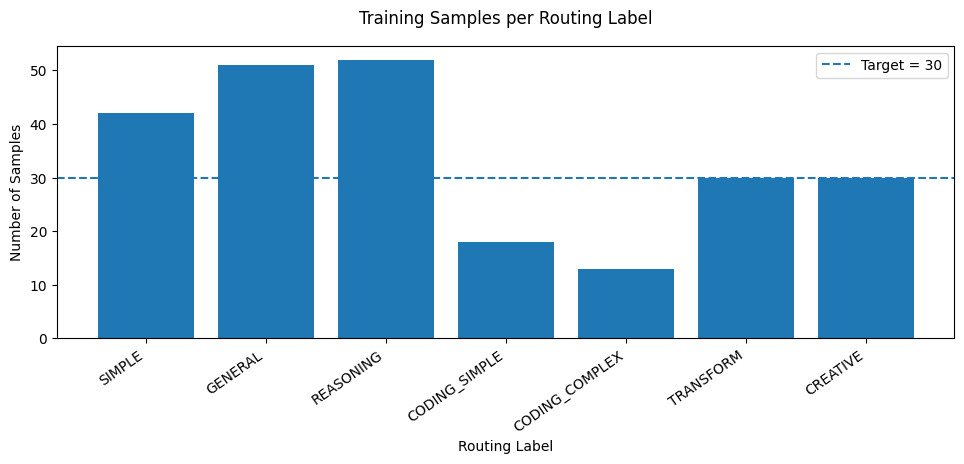


## Real Prompt Routing Test


,ID,Prompt,Route,Confidence,Second Choice,Second Score
0,1,berapa 15 persen dari 500,SIMPLE,0.260,REASONING,0.206
1,2,jelaskan fungsi docker compose,CODING_SIMPLE,0.302,GENERAL,0.174
2,3,bandingkan REST dan GraphQL untuk backend apli...,REASONING,0.315,GENERAL,0.220
3,4,buat regex untuk validasi email,CODING_SIMPLE,0.416,TRANSFORM,0.191
4,5,buat function python untuk parsing json,CODING_SIMPLE,0.311,GENERAL,0.149
5,6,debug kenapa service systemd restart terus dan...,CODING_COMPLEX,0.360,REASONING,0.228
6,7,ringkas tulisan ini menjadi lima poin,SIMPLE,0.316,TRANSFORM,0.277
7,8,terjemahkan kalimat ini ke bahasa Jepang,TRANSFORM,0.536,SIMPLE,0.141
8,9,buat cerita pendek tentang robot kecil,CREATIVE,0.420,TRANSFORM,0.175
9,10,kenapa request API direct cepat tapi lewat rou...,REASONING,0.449,CODING_COMPLEX,0.170


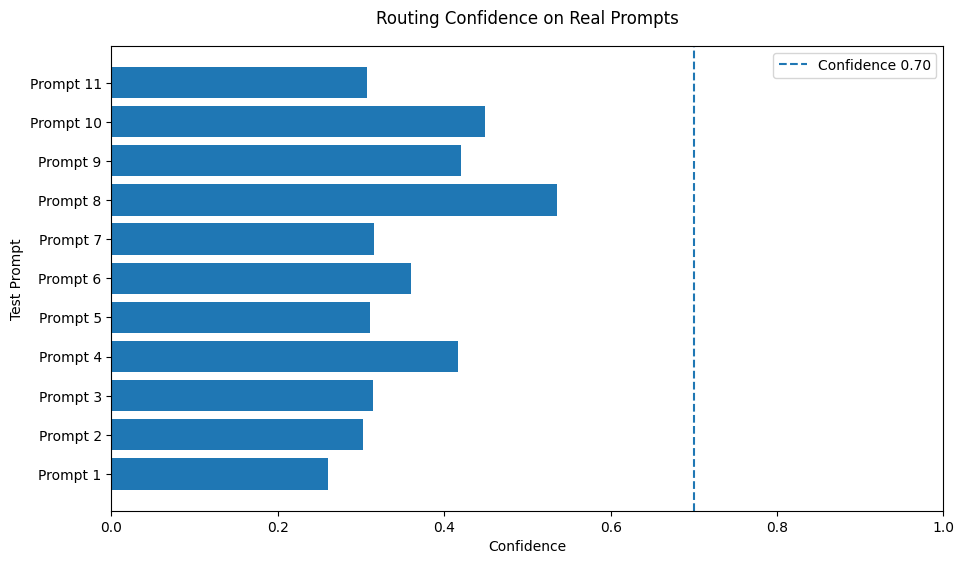


## Confusion Matrix


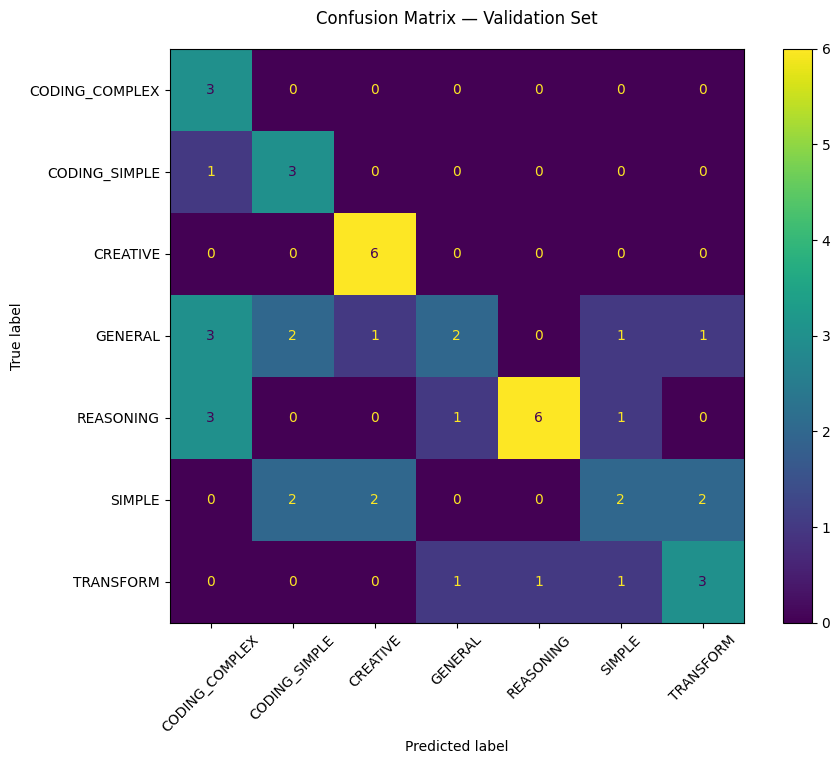


## Normalized Confusion Matrix


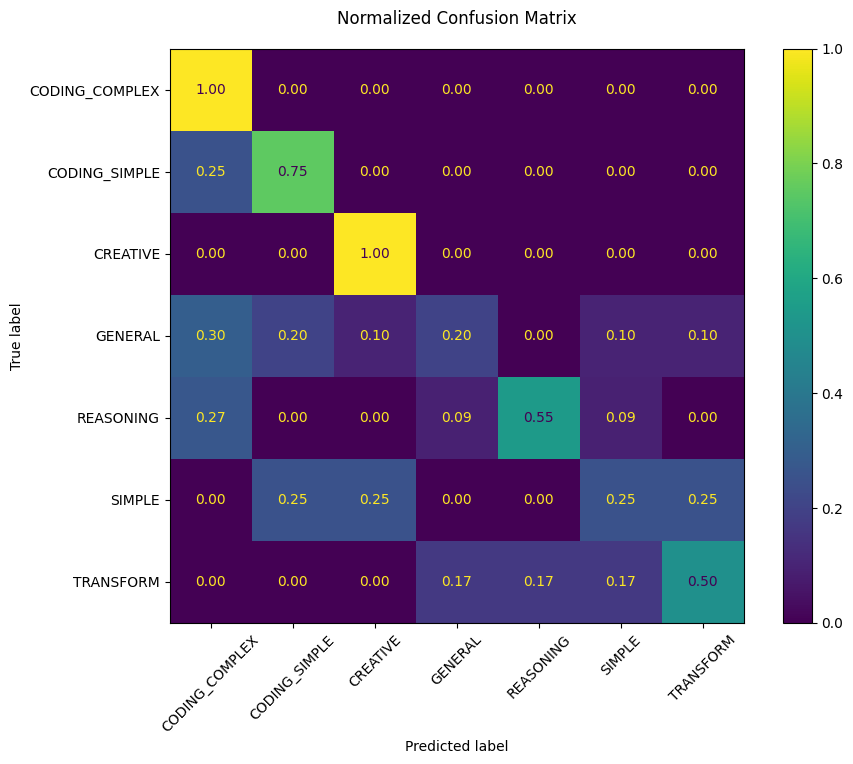


## Predicted Routes on Real Prompts


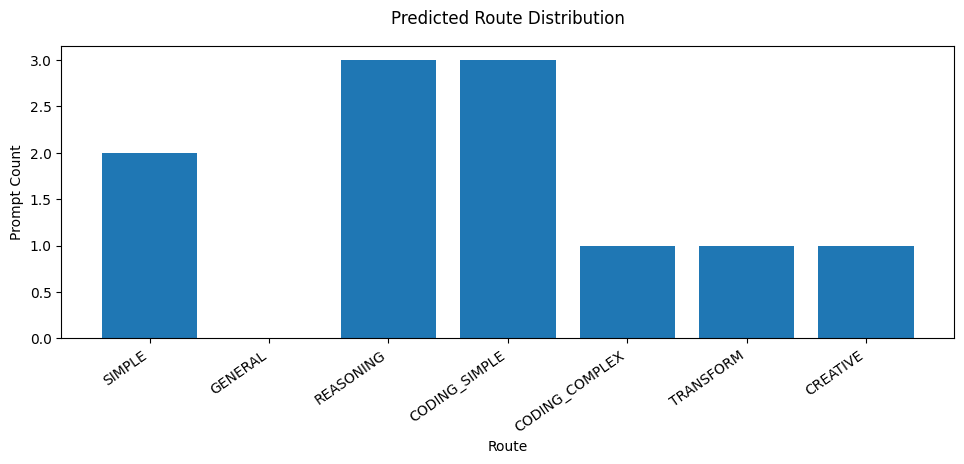


## Auto-Tuning History


,timestamp,samples,target_per_label,accuracy,macro_f1,count_SIMPLE,count_GENERAL,count_REASONING,count_CODING_SIMPLE,count_CODING_COMPLEX,count_TRANSFORM,count_CREATIVE
0,2026-08-23 10:14:42.151172,187,30,0.500000,0.393557,38,36,41,3,9,30,30
1,2026-08-23 10:32:06.542951,210,30,0.476190,0.424425,38,43,52,4,13,30,30
2,2026-08-23 11:10:38.039164,236,30,0.520833,0.509581,42,51,52,18,13,30,30


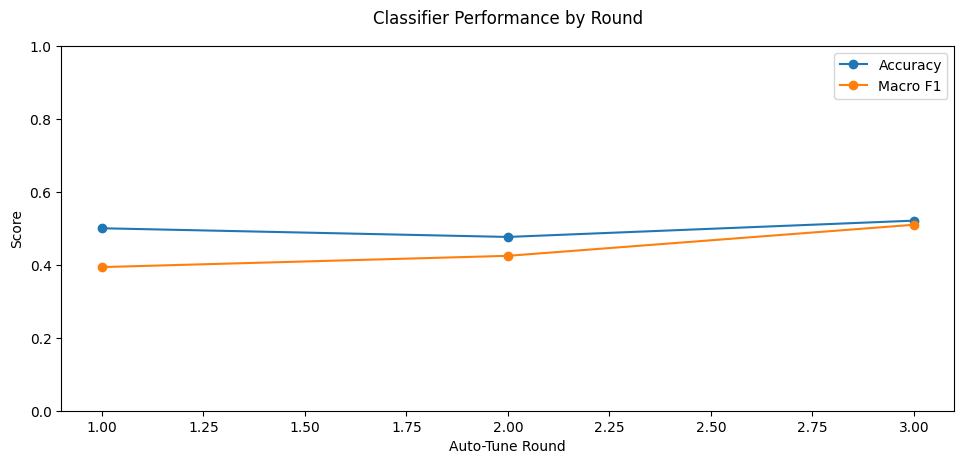



REPORT FINISHED


In [149]:
# =========================================================
# CHECK + VISUALIZE LAST ROUND — CLEAN VERSION
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

from IPython.display import display, Markdown


# =========================================================
# 1. HEADER + METRICS
# =========================================================

display(
    Markdown(
        """
# Router Classifier — Last Round Report
"""
    )
)

if metrics_current is not None:

    metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Macro F1",
                "Test Samples",
                "Total Dataset"
            ],
            "Value": [
                round(metrics_current["accuracy"], 3),
                round(metrics_current["macro_f1"], 3),
                metrics_current["test_samples"],
                len(df_balanced)
            ]
        }
    )

    display(metrics_df)

else:
    print("Metrics belum tersedia.")


# =========================================================
# 2. DATASET DISTRIBUTION
# =========================================================

display(
    Markdown(
        """
## Dataset Distribution
"""
    )
)

label_counts = (
    df_balanced["label"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
)

distribution_df = pd.DataFrame(
    {
        "Label": label_counts.index,
        "Samples": label_counts.values,
        "Target": TARGET_PER_LABEL,
    }
)

distribution_df["Remaining"] = (
    distribution_df["Target"]
    - distribution_df["Samples"]
).clip(lower=0)

display(distribution_df)


# =========================================================
# 3. PLOT DATASET DISTRIBUTION
# =========================================================

fig = plt.figure(figsize=(10, 5))

plt.bar(
    label_counts.index,
    label_counts.values
)

plt.axhline(
    TARGET_PER_LABEL,
    linestyle="--",
    linewidth=1.5,
    label=f"Target = {TARGET_PER_LABEL}"
)

plt.title(
    "Training Samples per Routing Label",
    pad=16
)

plt.xlabel("Routing Label")
plt.ylabel("Number of Samples")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend()

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 4. REAL PROMPT TEST
# =========================================================

display(
    Markdown(
        """
## Real Prompt Routing Test
"""
    )
)

if classifier_current is None:
    raise RuntimeError(
        "classifier_current belum tersedia."
    )

test_embeddings = embedding_model.encode(
    REAL_TEST_PROMPTS,
    normalize_embeddings=True
)

predictions = classifier_current.predict(
    test_embeddings
)

probabilities = classifier_current.predict_proba(
    test_embeddings
)


real_results = []

for i, (prompt, label, probs) in enumerate(
    zip(
        REAL_TEST_PROMPTS,
        predictions,
        probabilities
    ),
    start=1
):

    confidence = float(
        probs.max()
    )

    order = np.argsort(
        probs
    )[::-1]

    second_idx = order[1]

    real_results.append(
        {
            "ID": i,
            "Prompt": prompt,
            "Route": label,
            "Confidence": round(
                confidence,
                3
            ),
            "Second Choice":
                classifier_current.classes_[
                    second_idx
                ],
            "Second Score": round(
                float(
                    probs[
                        second_idx
                    ]
                ),
                3
            )
        }
    )


df_real_test = pd.DataFrame(
    real_results
)

display(df_real_test)


# =========================================================
# 5. CONFIDENCE PLOT
# =========================================================

fig = plt.figure(figsize=(10, 6))

positions = np.arange(
    len(df_real_test)
)

plt.barh(
    positions,
    df_real_test[
        "Confidence"
    ]
)

plt.yticks(
    positions,
    [
        f"Prompt {i}"
        for i in df_real_test["ID"]
    ]
)

plt.axvline(
    0.70,
    linestyle="--",
    linewidth=1.5,
    label="Confidence 0.70"
)

plt.xlim(
    0,
    1
)

plt.title(
    "Routing Confidence on Real Prompts",
    pad=16
)

plt.xlabel("Confidence")
plt.ylabel("Test Prompt")

plt.legend()

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 6. CONFUSION MATRIX
# =========================================================

display(
    Markdown(
        """
## Confusion Matrix
"""
    )
)

# Supaya confusion matrix valid,
# kita buat ulang test split yang sama dengan train_router()

X_all = embedding_model.encode(
    df_balanced["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=False,
    normalize_embeddings=True
)

y_all = df_balanced[
    "label"
].values


from sklearn.model_selection import train_test_split

(
    X_train_check,
    X_test_check,
    y_train_check,
    y_test_check
) = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

y_pred_check = classifier_current.predict(
    X_test_check
)

cm_labels = list(
    classifier_current.classes_
)

cm = confusion_matrix(
    y_test_check,
    y_pred_check,
    labels=cm_labels
)

fig = plt.figure(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cm_labels
)

disp.plot(
    ax=plt.gca(),
    values_format="d",
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix — Validation Set",
    pad=18
)

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 7. NORMALIZED CONFUSION MATRIX
# =========================================================

display(
    Markdown(
        """
## Normalized Confusion Matrix
"""
    )
)

cm_normalized = confusion_matrix(
    y_test_check,
    y_pred_check,
    labels=cm_labels,
    normalize="true"
)

fig = plt.figure(
    figsize=(10, 8)
)

disp_normalized = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=cm_labels
)

disp_normalized.plot(
    ax=plt.gca(),
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Normalized Confusion Matrix",
    pad=18
)

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 8. ROUTE DISTRIBUTION — REAL TEST
# =========================================================

display(
    Markdown(
        """
## Predicted Routes on Real Prompts
"""
    )
)

route_counts = (
    df_real_test[
        "Route"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

fig = plt.figure(
    figsize=(10, 5)
)

plt.bar(
    route_counts.index,
    route_counts.values
)

plt.title(
    "Predicted Route Distribution",
    pad=16
)

plt.xlabel("Route")
plt.ylabel("Prompt Count")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout(
    pad=2.0
)

plt.show()

print("\n")


# =========================================================
# 9. TUNING HISTORY
# =========================================================

display(
    Markdown(
        """
## Auto-Tuning History
"""
    )
)

if os.path.exists(
    ROUND_LOG_PATH
):

    history_df = pd.read_csv(
        ROUND_LOG_PATH
    )

    display(
        history_df.tail(10)
    )

    if len(history_df) >= 2:

        fig = plt.figure(
            figsize=(10, 5)
        )

        rounds = np.arange(
            1,
            len(history_df) + 1
        )

        plt.plot(
            rounds,
            history_df[
                "accuracy"
            ],
            marker="o",
            label="Accuracy"
        )

        plt.plot(
            rounds,
            history_df[
                "macro_f1"
            ],
            marker="o",
            label="Macro F1"
        )

        plt.ylim(
            0,
            1
        )

        plt.xlabel(
            "Auto-Tune Round"
        )

        plt.ylabel(
            "Score"
        )

        plt.title(
            "Classifier Performance by Round",
            pad=16
        )

        plt.legend()

        plt.tight_layout(
            pad=2.0
        )

        plt.show()

    else:
        print(
            "History baru punya 1 round. "
            "Grafik trend muncul setelah round berikutnya."
        )

else:

    print(
        "Round history belum tersedia."
    )


print("\n")
print("=" * 60)
print("REPORT FINISHED")
print("=" * 60)

In [142]:
# 1. COBA MOUNT DRIVE LAGI

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

import os

assert os.path.exists("/content/drive/MyDrive"), \
    "Google Drive belum mounted"

SAVE_DIR = "/content/drive/MyDrive/router_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Persistent storage OK:", SAVE_DIR)

Mounted at /content/drive
Persistent storage OK: /content/drive/MyDrive/router_classifier


In [143]:
import os

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# dataset terbaru dari RAM
df_balanced.to_csv(
    f"{SAVE_DIR}/router_dataset_current.csv",
    index=False
)

print(
    "Dataset saved:",
    len(df_balanced)
)

Dataset saved: 254


In [144]:
import shutil
import os

files_to_backup = [
    "router_teacher_checkpoint.csv",
    "router_teacher_extra_all.csv",
    "router_tuning_rounds.csv",
    "router_classifier_current.joblib",
]

for filename in files_to_backup:

    src = f"/content/{filename}"
    dst = f"{SAVE_DIR}/{filename}"

    if os.path.exists(src):

        shutil.copy2(
            src,
            dst
        )

        print(
            "Copied:",
            filename
        )

Copied: router_teacher_checkpoint.csv
Copied: router_teacher_extra_all.csv
Copied: router_tuning_rounds.csv
Copied: router_classifier_current.joblib


In [145]:
print("BASE:", BASE_PATH)
print("EXTRA:", EXTRA_ALL_PATH)
print("DATASET:", CURRENT_DATASET_PATH)
print("LOG:", ROUND_LOG_PATH)

BASE: /content/drive/MyDrive/router_classifier/router_teacher_checkpoint.csv
EXTRA: /content/drive/MyDrive/router_classifier/router_teacher_extra_all.csv
DATASET: /content/drive/MyDrive/router_classifier/router_dataset_current.csv
LOG: /content/drive/MyDrive/router_classifier/router_tuning_rounds.csv
